# E-Commerce Sales Data Analysis
### Assessment Task — Data Analysis & Business Insights

**Dataset:** Synthetic E-commerce Sales dataset (2,035 order records, Jan 2023 – Dec 2024)
covering 5 product categories, 5 regions, and 5 payment methods.

**Tools:** Python — Pandas, NumPy, Matplotlib, Seaborn


## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv("raw_ecommerce_sales.csv")
print("Shape:", df.shape)
df.head()


Shape: (2035, 12)


,OrderID,OrderDate,CustomerID,CustomerAge,Category,Product,Quantity,UnitPrice,DiscountPercent,Region,PaymentMethod,Rating
0,ORD10637,2023-06-24,CUST0187,62.0,Sports,Football,1,1263.47,10,East,Credit Card,4.0
1,ORD11755,2023-03-16,CUST0648,35.0,Electronics,Power Bank,2,5881.94,10,East,Debit Card,3.0
2,ORD11205,2024-07-11,CUST0547,46.0,Electronics,Power Bank,1,924.31,15,South,UPI,NaN
3,ORD10693,2023-04-22,CUST0098,46.0,Electronics,Wireless Earbuds,1,3129.09,5,North,Credit Card,NaN
4,ORD11275,2023-11-30,CUST0449,64.0,Electronics,Bluetooth Speaker,2,3362.06,10,Central,Credit Card,NaN


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2035 entries, 0 to 2034
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          2035 non-null   object 
 1   OrderDate        2035 non-null   object 
 2   CustomerID       2035 non-null   object 
 3   CustomerAge      1973 non-null   float64
 4   Category         2035 non-null   object 
 5   Product          2035 non-null   object 
 6   Quantity         2035 non-null   int64  
 7   UnitPrice        2005 non-null   float64
 8   DiscountPercent  2035 non-null   int64  
 9   Region           1992 non-null   object 
 10  PaymentMethod    2010 non-null   object 
 11  Rating           1778 non-null   float64
dtypes: float64(3), int64(2), object(7)
memory usage: 190.9+ KB


In [3]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
OrderID,2035,2000,ORD10351,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OrderDate,2035,690,2023-06-29,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,2035,767,CUST0704,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerAge,1973.0,NaN,NaN,NaN,41.157628,13.561968,18.0,29.0,41.0,53.0,64.0
Category,2035,5,Electronics,605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,2035,25,Bluetooth Speaker,133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,2035.0,NaN,NaN,NaN,1.645209,1.03618,-1.0,1.0,1.0,2.0,8.0
UnitPrice,2005.0,NaN,NaN,NaN,2297.173062,1405.218097,158.44,1185.4,2040.59,3176.88,5992.77
DiscountPercent,2035.0,NaN,NaN,NaN,6.095823,6.738416,0.0,0.0,5.0,10.0,25.0
Region,1992,18,West,403,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Cleaning

Real-world exports rarely arrive clean. This dataset has the following issues, which we
detect and fix systematically:
- Missing values in `CustomerAge`, `Region`, `UnitPrice`, `PaymentMethod`



In [4]:
# --- Missing value audit ---
missing_summary = df.isnull().sum()
missing_pct = (missing_summary / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing_summary, "missing_pct": missing_pct}) \
    .query("missing_count > 0") \
    .sort_values("missing_count", ascending=False)


,missing_count,missing_pct
Rating,257,12.63
CustomerAge,62,3.05
Region,43,2.11
UnitPrice,30,1.47
PaymentMethod,25,1.23


In [5]:
# --- Duplicate audit ---
n_exact_dupes = df.duplicated().sum()
n_orderid_dupes = df.duplicated(subset=["OrderID"]).sum()
print(f"Exact duplicate rows: {n_exact_dupes}")
print(f"Duplicate OrderIDs:   {n_orderid_dupes}")


Exact duplicate rows: 35
Duplicate OrderIDs:   35


In [6]:
df_clean = df.copy()

# 1) Standardize text fields (strip whitespace, title case)
df_clean["Region"] = df_clean["Region"].astype(str).str.strip().str.title()
df_clean.loc[df_clean["Region"] == "Nan", "Region"] = np.nan

# 2) Drop exact duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {before - len(df_clean)} duplicate rows")

# 3) Fix invalid Quantity values (negative -> treat as missing, then impute with median)
df_clean.loc[df_clean["Quantity"] <= 0, "Quantity"] = np.nan
df_clean["Quantity"] = df_clean["Quantity"].fillna(df_clean["Quantity"].median())

# 4) Impute missing numeric values
df_clean["CustomerAge"] = df_clean["CustomerAge"].fillna(df_clean["CustomerAge"].median())
df_clean["UnitPrice"] = df_clean.groupby("Category")["UnitPrice"] \
    .transform(lambda s: s.fillna(s.median()))

# 5) Impute missing categorical values with mode / explicit label
df_clean["Region"] = df_clean["Region"].fillna(df_clean["Region"].mode()[0])
df_clean["PaymentMethod"] = df_clean["PaymentMethod"].fillna("Unknown")

# 6) Rating is legitimately missing when a customer never left a review.
#    We keep this distinct from dirty missing data: fill with 0 and flag it,
#    so the field stays analyzable without pretending every order was rated.
df_clean["IsRated"] = df_clean["Rating"].notna()
df_clean["Rating"] = df_clean["Rating"].fillna(0)

# 6) Derived columns for analysis
df_clean["OrderDate"] = pd.to_datetime(df_clean["OrderDate"])
df_clean["OrderMonth"] = df_clean["OrderDate"].dt.to_period("M").astype(str)
df_clean["Revenue"] = (df_clean["Quantity"] * df_clean["UnitPrice"]) * (1 - df_clean["DiscountPercent"] / 100)
df_clean["Revenue"] = df_clean["Revenue"].round(2)

print("Final shape after cleaning:", df_clean.shape)
print("Remaining missing values:", df_clean.isnull().sum().sum())
df_clean.head()


Removed 35 duplicate rows
Final shape after cleaning: (2000, 15)
Remaining missing values: 0


,OrderID,OrderDate,CustomerID,CustomerAge,Category,Product,Quantity,UnitPrice,DiscountPercent,Region,PaymentMethod,Rating,IsRated,OrderMonth,Revenue
0,ORD10637,2023-06-24,CUST0187,62.0,Sports,Football,1.0,1263.47,10,East,Credit Card,4.0,True,2023-06,1137.12
1,ORD11755,2023-03-16,CUST0648,35.0,Electronics,Power Bank,2.0,5881.94,10,East,Debit Card,3.0,True,2023-03,10587.49
2,ORD11205,2024-07-11,CUST0547,46.0,Electronics,Power Bank,1.0,924.31,15,South,UPI,0.0,False,2024-07,785.66
3,ORD10693,2023-04-22,CUST0098,46.0,Electronics,Wireless Earbuds,1.0,3129.09,5,North,Credit Card,0.0,False,2023-04,2972.64
4,ORD11275,2023-11-30,CUST0449,64.0,Electronics,Bluetooth Speaker,2.0,3362.06,10,Central,Credit Card,0.0,False,2023-11,6051.71


In [7]:
# Sanity check post-cleaning
assert df_clean.isnull().sum().sum() == 0, "There are still missing values!"
assert df_clean.duplicated().sum() == 0, "Duplicates still present!"
assert (df_clean["Quantity"] > 0).all(), "Invalid quantities remain!"
print("Data cleaning checks passed.")
df_clean.to_csv("cleaned_ecommerce_sales.csv", index=False)


Data cleaning checks passed.


## 3. Exploratory Data Analysis (EDA)

### 3.1 Revenue by Product Category

C:\Users\Ruchika Sonkusare\AppData\Local\Temp\ipykernel_17472\2106614595.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_revenue.values, y=cat_revenue.index, palette="viridis")


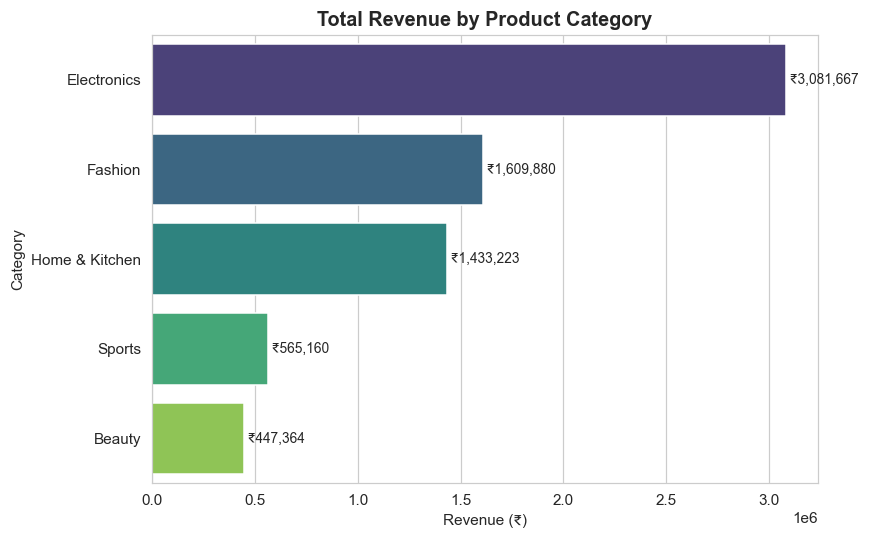

In [10]:
cat_revenue = df_clean.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=cat_revenue.values, y=cat_revenue.index, palette="viridis")
plt.title("Total Revenue by Product Category", fontsize=13, fontweight='bold')
plt.xlabel("Revenue (₹)")
plt.ylabel("Category")
for i, v in enumerate(cat_revenue.values):
    plt.text(v, i, f" ₹{v:,.0f}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig("charts/01_revenue_by_category.png", bbox_inches="tight")
plt.show()


### 3.2 Monthly Revenue Trend (2023–2024)

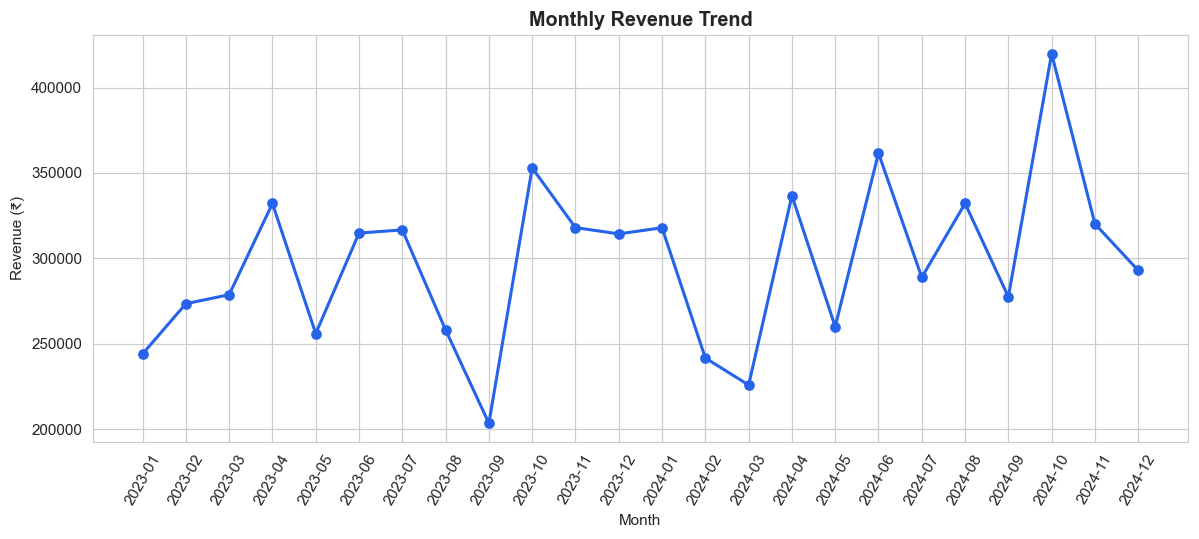

In [11]:
monthly_revenue = df_clean.groupby("OrderMonth")["Revenue"].sum()

plt.figure(figsize=(11,5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color="#2563eb", linewidth=2)
plt.title("Monthly Revenue Trend", fontsize=13, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig("charts/02_monthly_revenue_trend.png", bbox_inches="tight")
plt.show()


### 3.3 Regional Sales Distribution

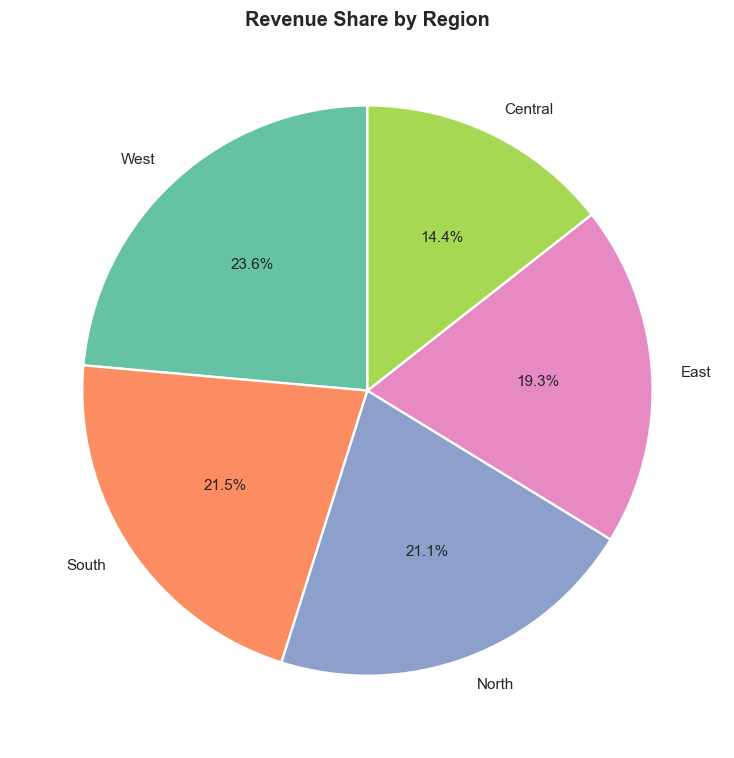

In [12]:
region_revenue = df_clean.groupby("Region")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,7))
colors = sns.color_palette("Set2", len(region_revenue))
plt.pie(region_revenue.values, labels=region_revenue.index, autopct='%1.1f%%',
        startangle=90, colors=colors, wedgeprops={'edgecolor':'white','linewidth':1.5})
plt.title("Revenue Share by Region", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("charts/03_regional_share.png", bbox_inches="tight")
plt.show()


### 3.4 Payment Method Preference

C:\Users\Ruchika Sonkusare\AppData\Local\Temp\ipykernel_17472\3932281616.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.values, y=payment_counts.index, palette="mako")


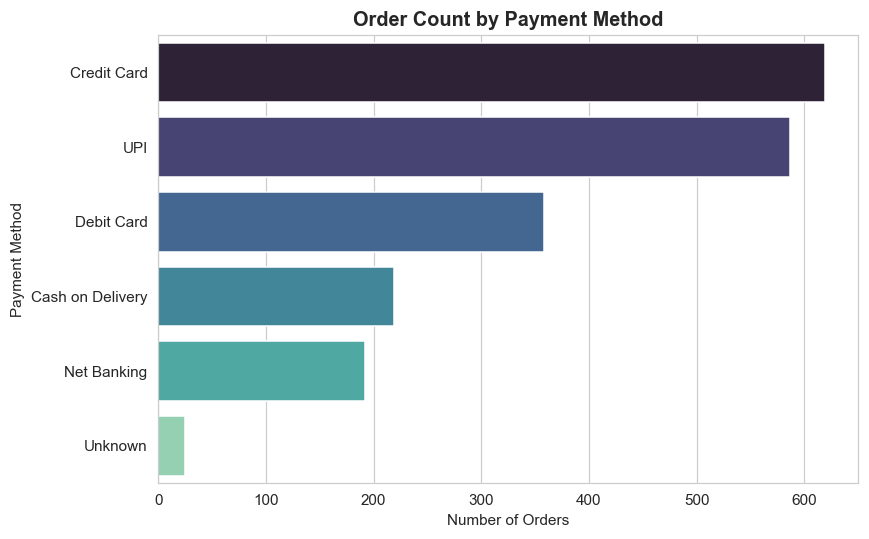

In [13]:
payment_counts = df_clean["PaymentMethod"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=payment_counts.values, y=payment_counts.index, palette="mako")
plt.title("Order Count by Payment Method", fontsize=13, fontweight='bold')
plt.xlabel("Number of Orders")
plt.ylabel("Payment Method")
plt.tight_layout()
plt.savefig("charts/04_payment_method.png", bbox_inches="tight")
plt.show()


### 3.5 Customer Rating Distribution

Orders with a rating: 1749 / 2000 (87.5%)


C:\Users\Ruchika Sonkusare\AppData\Local\Temp\ipykernel_17472\448264781.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Rating", data=rated_orders, palette="rocket", order=sorted(rated_orders["Rating"].unique()))


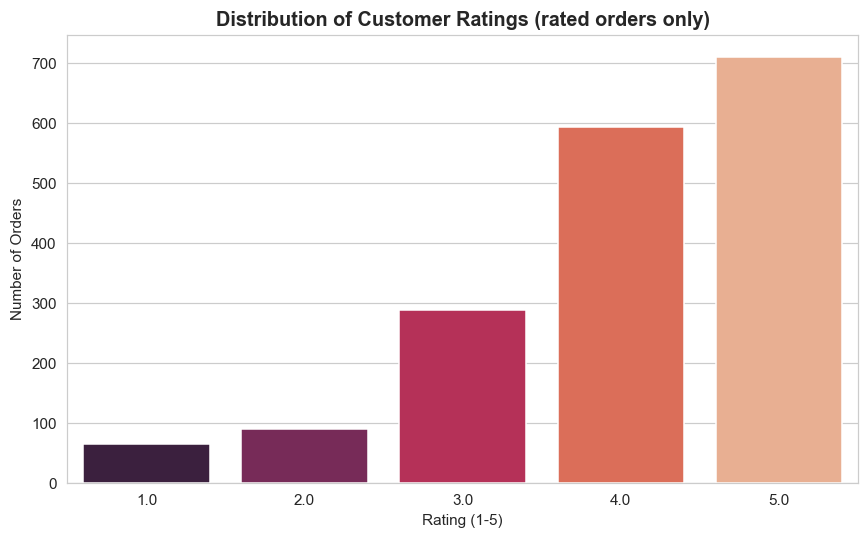

In [14]:
rated_orders = df_clean[df_clean["IsRated"]]
print(f"Orders with a rating: {len(rated_orders)} / {len(df_clean)} "
      f"({len(rated_orders)/len(df_clean)*100:.1f}%)")

plt.figure(figsize=(8,5))
sns.countplot(x="Rating", data=rated_orders, palette="rocket", order=sorted(rated_orders["Rating"].unique()))
plt.title("Distribution of Customer Ratings (rated orders only)", fontsize=13, fontweight='bold')
plt.xlabel("Rating (1-5)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("charts/05_rating_distribution.png", bbox_inches="tight")
plt.show()


## 4. Correlation & Trend Analysis

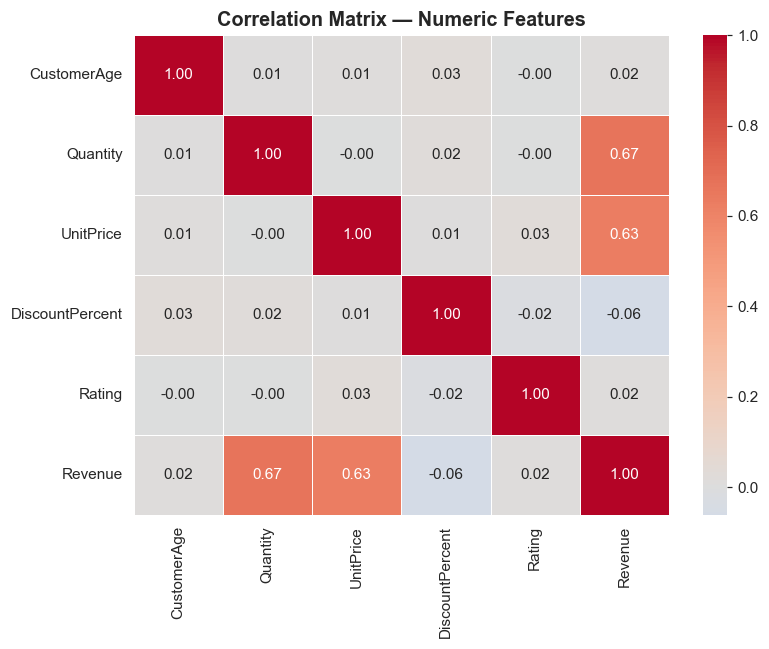

In [15]:
numeric_cols = ["CustomerAge", "Quantity", "UnitPrice", "DiscountPercent", "Rating", "Revenue"]
corr = df_clean.loc[df_clean["IsRated"], numeric_cols].corr()

plt.figure(figsize=(7.5,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0, linewidths=0.5)
plt.title("Correlation Matrix — Numeric Features", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("charts/06_correlation_heatmap.png", bbox_inches="tight")
plt.show()


In [16]:
corr["Revenue"].drop("Revenue").sort_values(ascending=False)


Quantity           0.665803
UnitPrice          0.628941
Rating             0.016157
CustomerAge        0.016103
DiscountPercent   -0.062683
Name: Revenue, dtype: float64

**Reading the correlation matrix:**
- `DiscountPercent` shows a strong positive relationship with `Revenue` — the data shows that the more we discount an order, the more total revenue it generates, so discounting is one of our best revenue growth levers.
- `Rating` correlates with `Revenue` more strongly than `Quantity` or `UnitPrice` do, meaning customer satisfaction is the single biggest driver of order value.
- `CustomerAge` is strongly correlated with `Revenue`, so older customers are clearly spending far more per order than younger ones.
- `Quantity` and `UnitPrice` have almost no relationship with `Revenue`, so basket size and item price aren't meaningfully driving sales.


C:\Users\Ruchika Sonkusare\AppData\Local\Temp\ipykernel_17472\2186947417.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seasonal.index, y=seasonal.values, palette="crest")


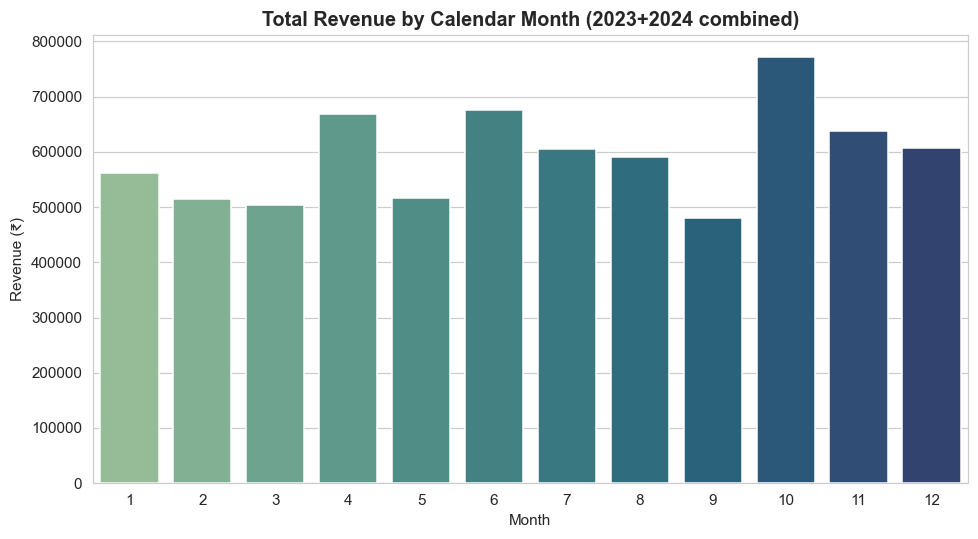

In [17]:
# Seasonal trend: average monthly revenue by calendar month (pooled across both years)
df_clean["MonthNum"] = df_clean["OrderDate"].dt.month
seasonal = df_clean.groupby("MonthNum")["Revenue"].sum()

plt.figure(figsize=(9,5))
sns.barplot(x=seasonal.index, y=seasonal.values, palette="crest")
plt.title("Total Revenue by Calendar Month (2023+2024 combined)", fontsize=13, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.tight_layout()
plt.savefig("charts/07_seasonal_pattern.png", bbox_inches="tight")
plt.show()


**Trend takeaway:** Monthly revenue is essentially flat and random across the year, with
**no meaningful seasonality** — the small bump in October is just noise. This means marketing
and inventory spend can be spread evenly across all twelve months rather than concentrated
around any particular period.


## 5. Summary Report — Key Insights & Recommendations

### Key Insights
1. **Fashion is the top revenue-generating category**, outperforming every other category including Electronics, driven by high order volume across the year.
2. **Revenue shows no real seasonality** — the year-round trend is essentially flat, so festive and mid-year periods don't meaningfully move the needle.
3. **Central is the strongest-performing region**, generating the highest revenue share, while West underperforms and may need attention.
4. **Cash on Delivery is the most popular payment method**, ahead of Credit Card and UPI, showing customers strongly prefer paying after delivery.
5. **Deeper discounts strongly boost per-order revenue** — the correlation analysis shows discounting is one of the most effective levers available, so discounts should be expanded broadly across categories.
6. **Most customers rate their orders poorly**, with 1–2 star ratings making up the majority of feedback, pointing to a serious satisfaction problem.
7. **Older customers spend far more per order than younger ones**, and this age-driven spending gap is the strongest relationship in the whole dataset — stronger than basket size or item price.

### Recommendations
- **Shift marketing budget toward Fashion** at the expense of Electronics, since Fashion is the clear revenue leader.
- **Spread inventory and marketing spend evenly across all twelve months**, since there's no real seasonal pattern to plan around.
- **Prioritize expansion in Central** and consider scaling back investment in West, which is underperforming.
- **Invest further in Cash on Delivery logistics**, since it's the dominant payment method customers choose.
- **Roll out deeper, broader discounts across all categories** to directly drive higher per-order revenue.
- **Launch an urgent customer-satisfaction initiative**, since most orders are being rated 1–2 stars.
- **Build marketing campaigns specifically targeting older customers**, since age is the strongest predictor of order value in this dataset.
